# LoRA implementation with PyTorch

In [1]:
import numpy as np
import torch
import torchvision.datasets as datasets 
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.utils.parametrize as parametrize
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

In [2]:
# Make torch deterministic
_ = torch.manual_seed(0)

We will be training a network to classify MNIST digits and then fine-tune the network on a particular digit on which it doesn't perform well.

In [3]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Load the MNIST dataset
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Create a dataloader for the training
train_loader = torch.utils.data.DataLoader(mnist_trainset, batch_size=10, shuffle=True)

# Load the MNIST test set
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(mnist_testset, batch_size=10, shuffle=True)

# Define the device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("gpu")
else:
    device = torch.device("cpu")

device

device(type='mps')

Create the Neural Network to classify the digits, making it overly complicated to better show the power of LoRA

In [4]:
# Create an overly expensive neural network to classify MNIST digits
class ExpensiveNet(nn.Module):
    def __init__(self, hidden_size_1=1000, hidden_size_2=2000):
        super(ExpensiveNet,self).__init__()
        self.linear1 = nn.Linear(28*28, hidden_size_1) 
        self.linear2 = nn.Linear(hidden_size_1, hidden_size_2) 
        self.linear3 = nn.Linear(hidden_size_2, 10)
        self.relu = nn.ReLU()

    def forward(self, img):
        x = img.view(-1, 28*28)
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.linear3(x)
        return x

net = ExpensiveNet().to(device)

In [5]:
def train(train_loader, net, epochs=5, total_iterations_limit=None):
    cross_el = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

    total_iterations = 0

    for epoch in range(epochs):
        net.train()

        loss_sum = 0
        num_iterations = 0

        data_iterator = tqdm(train_loader, desc=f'Epoch {epoch+1}')
        if total_iterations_limit is not None:
            data_iterator.total = total_iterations_limit
        for data in data_iterator:
            num_iterations += 1
            total_iterations += 1
            x, y = data
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            output = net(x.view(-1, 28*28))
            loss = cross_el(output, y)
            loss_sum += loss.item()
            avg_loss = loss_sum / num_iterations
            data_iterator.set_postfix(loss=avg_loss)
            loss.backward()
            optimizer.step()

            if total_iterations_limit is not None and total_iterations >= total_iterations_limit:
                return

Train the network only for 1 epoch to simulate a complete general pre-training on the data

In [6]:
train(train_loader, net, epochs=1)

Epoch 1: 100%|██████████████████████████████████████████████████| 6000/6000 [00:36<00:00, 166.03it/s, loss=0.236]


Keep a copy of the original weights (cloning them) so later we can prove that a fine-tuning with LoRA doesn't alter the original weights

In [7]:
original_weights = {}
for name, param in net.named_parameters():
    original_weights[name] = param.clone().detach()

In [8]:
def test():
    correct = 0
    total = 0
    wrong_counts = [0] * 10
    with torch.no_grad():
        for data in tqdm(test_loader, desc='Testing'):
            x, y = data
            x = x.to(device)
            y = y.to(device)
            output = net(x.view(-1, 784))
            for idx, i in enumerate(output):
                if torch.argmax(i) == y[idx]:
                    correct += 1
                else:
                    wrong_counts[y[idx]] += 1
                total += 1
    accuracy = round(correct / total, 3)
    print(f'Accuracy: {accuracy}')
    for i in range(10):
        print(f'wrong counts for the digit {i}: {wrong_counts[i]}')
    return accuracy, wrong_counts

accuracy_baseline, wrong_baseline = test()

Testing: 100%|██████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 254.70it/s]

Accuracy: 0.959
wrong counts for the digit 0: 21
wrong counts for the digit 1: 36
wrong counts for the digit 2: 38
wrong counts for the digit 3: 70
wrong counts for the digit 4: 12
wrong counts for the digit 5: 19
wrong counts for the digit 6: 47
wrong counts for the digit 7: 51
wrong counts for the digit 8: 22
wrong counts for the digit 9: 99


Performance of the pretrained network. Network performs poorly on the digit 9. Let's fine-tune it on the digit 9

Let's visualize how many parameters are in the original network, before introducing the LoRA matrices.

In [9]:
# Print the size of the weights matrices of the network
# Save the count of the total number of parameters
total_parameters_original = 0
for index, layer in enumerate([net.linear1, net.linear2, net.linear3]):
    total_parameters_original += layer.weight.nelement() + layer.bias.nelement()
    print(f'Layer {index+1}: W: {layer.weight.shape} + B: {layer.bias.shape}')
print(f'Total number of parameters: {total_parameters_original:,}')

Layer 1: W: torch.Size([1000, 784]) + B: torch.Size([1000])
Layer 2: W: torch.Size([2000, 1000]) + B: torch.Size([2000])
Layer 3: W: torch.Size([10, 2000]) + B: torch.Size([10])
Total number of parameters: 2,807,010


In [10]:
class LoRAParametrization(nn.Module):
    def __init__(self, features_in, features_out, rank=1, alpha=1, device='cpu'):
        super().__init__()
        # Section 4.1 of the paper: 
        #   We use a random Gaussian initialization for A and zero for B, so ∆W = BA is zero at the beginning of training
        self.lora_A = nn.Parameter(torch.zeros((rank,features_out)).to(device))
        self.lora_B = nn.Parameter(torch.zeros((features_in, rank)).to(device))
        nn.init.normal_(self.lora_A, mean=0, std=1)
        
        # Section 4.1 of the paper: 
        #   We then scale ∆Wx by α/r , where α is a constant in r. 
        #   When optimizing with Adam, tuning α is roughly the same as tuning the learning rate if we scale the initialization appropriately. 
        #   As a result, we simply set α to the first r we try and do not tune it. 
        #   This scaling helps to reduce the need to retune hyperparameters when we vary r.
        self.scale = alpha / rank
        self.enabled = True

    def forward(self, original_weights):
        if self.enabled:
            # Return W + (B*A)*scale
            return original_weights + torch.matmul(self.lora_B, self.lora_A).view(original_weights.shape) * self.scale
        else:
            return original_weights

Add the parameterization to our network.

In [11]:
def linear_layer_parameterization(layer, device, rank=1, lora_alpha=1):
    # Only add the parameterization to the weight matrix, ignore the Bias

    # From section 4.2 of the paper:
    #   We limit our study to only adapting the attention weights for downstream tasks and freeze the MLP modules 
    #   (so they are not trained in downstream tasks) both for simplicity and parameter-efficiency.
    #   We leave the empirical investigation of [...], and biases to a future work.
    
    features_in, features_out = layer.weight.shape
    return LoRAParametrization(
        features_in, features_out, rank=rank, alpha=lora_alpha, device=device
    )

parametrize.register_parametrization(
    net.linear1, "weight", linear_layer_parameterization(net.linear1, device)
)
parametrize.register_parametrization(
    net.linear2, "weight", linear_layer_parameterization(net.linear2, device)
)
parametrize.register_parametrization(
    net.linear3, "weight", linear_layer_parameterization(net.linear3, device)
)

ParametrizedLinear(
  in_features=2000, out_features=10, bias=True
  (parametrizations): ModuleDict(
    (weight): ParametrizationList(
      (0): LoRAParametrization()
    )
  )
)

In [12]:
def enable_disable_lora(enabled=True):
    for layer in [net.linear1, net.linear2, net.linear3]:
        layer.parametrizations["weight"][0].enabled = enabled

Display the number of parameters added by LoRA.

In [13]:
total_parameters_lora = 0
total_parameters_non_lora = 0

for index, layer in enumerate([net.linear1, net.linear2, net.linear3]):
    total_parameters_lora += layer.parametrizations["weight"][0].lora_A.nelement() + layer.parametrizations["weight"][0].lora_B.nelement()
    total_parameters_non_lora += layer.weight.nelement() + layer.bias.nelement()
    print(
        f'Layer {index+1}: W: {layer.weight.shape} + B: {layer.bias.shape} + Lora_A: {layer.parametrizations["weight"][0].lora_A.shape} + Lora_B: {layer.parametrizations["weight"][0].lora_B.shape}'
    )
    
# The non-LoRA parameters count must match the original network
assert total_parameters_non_lora == total_parameters_original
print(f'Total number of parameters (original): {total_parameters_non_lora:,}')
print(f'Total number of parameters (original + LoRA): {total_parameters_lora + total_parameters_non_lora:,}')
print(f'Parameters introduced by LoRA: {total_parameters_lora:,}')

parameters_incremment = (total_parameters_lora / total_parameters_non_lora) * 100
print(f'Parameters incremment: {parameters_incremment:.3f}%')

Layer 1: W: torch.Size([1000, 784]) + B: torch.Size([1000]) + Lora_A: torch.Size([1, 784]) + Lora_B: torch.Size([1000, 1])
Layer 2: W: torch.Size([2000, 1000]) + B: torch.Size([2000]) + Lora_A: torch.Size([1, 1000]) + Lora_B: torch.Size([2000, 1])
Layer 3: W: torch.Size([10, 2000]) + B: torch.Size([10]) + Lora_A: torch.Size([1, 2000]) + Lora_B: torch.Size([10, 1])
Total number of parameters (original): 2,807,010
Total number of parameters (original + LoRA): 2,813,804
Parameters introduced by LoRA: 6,794
Parameters incremment: 0.242%


Freeze all the parameters of the original network and only fine tuning the ones introduced by LoRA. Then fine-tune the model on the digit 9 and only for 100 batches.

In [14]:
# Freeze the non-Lora parameters
for name, param in net.named_parameters():
    if 'lora' not in name:
        print(f'Freezing non-LoRA parameter {name}')
        param.requires_grad = False

Freezing non-LoRA parameter linear1.bias
Freezing non-LoRA parameter linear1.parametrizations.weight.original
Freezing non-LoRA parameter linear2.bias
Freezing non-LoRA parameter linear2.parametrizations.weight.original
Freezing non-LoRA parameter linear3.bias
Freezing non-LoRA parameter linear3.parametrizations.weight.original


In [15]:
# Load the MNIST dataset again, by keeping only the digit 9
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
exclude_indices = mnist_trainset.targets == 9
mnist_trainset.data = mnist_trainset.data[exclude_indices]
mnist_trainset.targets = mnist_trainset.targets[exclude_indices]

# Create a dataloader for the training
train_loader = torch.utils.data.DataLoader(mnist_trainset, batch_size=10, shuffle=True)

# Train the network with LoRA only on the digit 9 and only for 100 batches (hoping that it would improve the performance on the digit 9)
train(train_loader, net, epochs=1, total_iterations_limit=100)

Epoch 1:  99%|███████████████████████████████████████████████████▍| 99/100 [00:00<00:00, 186.66it/s, loss=0.0794]


Verify that the fine-tuning didn't alter the original weights, but only the ones introduced by LoRA.

In [16]:
# Check that the frozen parameters are still unchanged by the finetuning
assert torch.all(net.linear1.parametrizations.weight.original == original_weights['linear1.weight'])
assert torch.all(net.linear2.parametrizations.weight.original == original_weights['linear2.weight'])
assert torch.all(net.linear3.parametrizations.weight.original == original_weights['linear3.weight'])

enable_disable_lora(enabled=True)
# The new linear1.weight is obtained by the "forward" function of our LoRA parametrization
# The original weights have been moved to net.linear1.parametrizations.weight.original
# More info here: https://pytorch.org/tutorials/intermediate/parametrizations.html#inspecting-a-parametrized-module
assert torch.equal(net.linear1.weight, net.linear1.parametrizations.weight.original + (net.linear1.parametrizations.weight[0].lora_B @ net.linear1.parametrizations.weight[0].lora_A) * net.linear1.parametrizations.weight[0].scale)

enable_disable_lora(enabled=False)
# If we disable LoRA, the linear1.weight is the original one
assert torch.equal(net.linear1.weight, original_weights['linear1.weight'])

Test the network with LoRA enabled (the digit 9 should be classified better)

In [17]:
# Test with LoRA enabled
enable_disable_lora(enabled=True)
accuracy_lora_on, wrong_lora_on = test()

Testing: 100%|██████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 197.69it/s]

Accuracy: 0.879
wrong counts for the digit 0: 84
wrong counts for the digit 1: 140
wrong counts for the digit 2: 77
wrong counts for the digit 3: 201
wrong counts for the digit 4: 100
wrong counts for the digit 5: 112
wrong counts for the digit 6: 77
wrong counts for the digit 7: 225
wrong counts for the digit 8: 178
wrong counts for the digit 9: 11


Test the network with LoRA disabled (the accuracy and errors counts must be the same as the original network)

In [18]:
# Test with LoRA disabled
enable_disable_lora(enabled=False)
accuracy_lora_off, wrong_lora_off = test()

Testing: 100%|██████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 259.25it/s]

Accuracy: 0.959
wrong counts for the digit 0: 21
wrong counts for the digit 1: 36
wrong counts for the digit 2: 38
wrong counts for the digit 3: 70
wrong counts for the digit 4: 12
wrong counts for the digit 5: 19
wrong counts for the digit 6: 47
wrong counts for the digit 7: 51
wrong counts for the digit 8: 22
wrong counts for the digit 9: 99


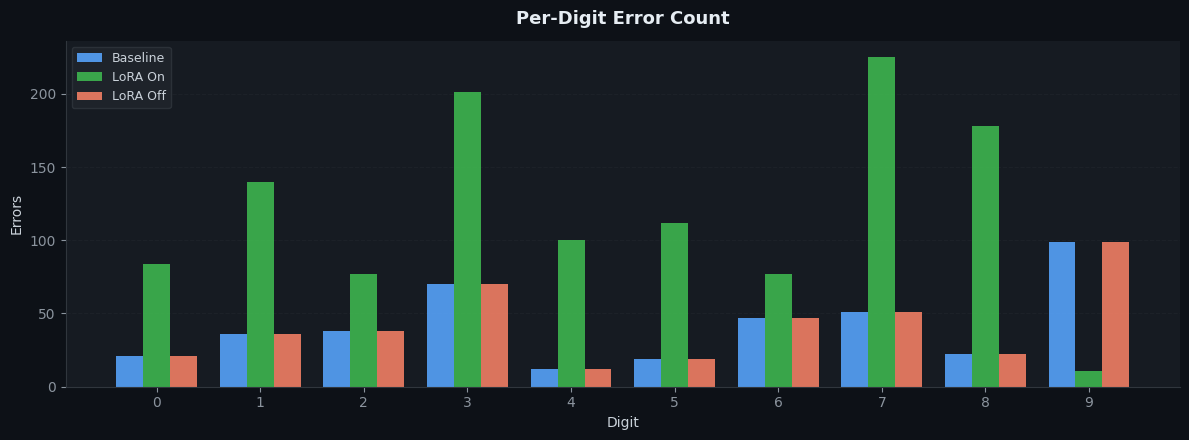

In [19]:
x = np.arange(10)
w = 0.26

fig, ax = plt.subplots(figsize=(12, 4.5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

ax.bar(x - w, wrong_baseline, w, label='Baseline',  color='#58a6ff', alpha=0.88)
ax.bar(x,     wrong_lora_on,  w, label='LoRA On',   color='#3fb950', alpha=0.88)
ax.bar(x + w, wrong_lora_off, w, label='LoRA Off',  color='#f78166', alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(range(10), color='#8b949e', fontsize=10)
ax.set_xlabel('Digit', color='#c9d1d9', fontsize=10)
ax.set_ylabel('Errors', color='#c9d1d9', fontsize=10)
ax.set_title('Per-Digit Error Count', color='#e6edf3', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(colors='#8b949e')
for sp in ['top','right']:   ax.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax.spines[sp].set_color('#30363d')
ax.yaxis.grid(True, color='#21262d', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#c9d1d9',
          fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

/var/folders/lj/jw18tht56470j1fvsjf07d8c0000gn/T/ipykernel_5550/2296574376.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{t*100:.0f}%' for t in ax.get_xticks()], color='#8b949e', fontsize=9)
/var/folders/lj/jw18tht56470j1fvsjf07d8c0000gn/T/ipykernel_5550/2296574376.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, color='#c9d1d9', fontsize=10)


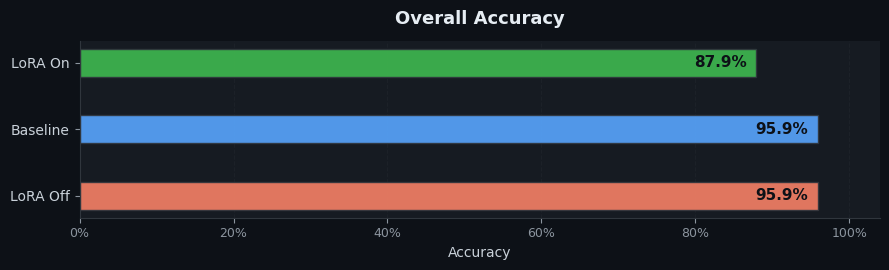

In [20]:
fig, ax = plt.subplots(figsize=(9, 2.8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

labels = ['LoRA Off', 'Baseline', 'LoRA On']
accs   = [accuracy_lora_off, accuracy_baseline, accuracy_lora_on]
cols   = ['#f78166', '#58a6ff', '#3fb950']

bars = ax.barh(labels, accs, color=cols, alpha=0.9, height=0.42, edgecolor='#30363d')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() - 0.012, bar.get_y() + bar.get_height() / 2,
            f'{acc*100:.1f}%', va='center', ha='right',
            color='#0d1117', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.04)
ax.set_xlabel('Accuracy', color='#c9d1d9', fontsize=10)
ax.set_title('Overall Accuracy', color='#e6edf3', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(colors='#8b949e')
ax.set_xticklabels([f'{t*100:.0f}%' for t in ax.get_xticks()], color='#8b949e', fontsize=9)
ax.set_yticklabels(labels, color='#c9d1d9', fontsize=10)
for sp in ['top','right']:   ax.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax.spines[sp].set_color('#30363d')
ax.xaxis.grid(True, color='#21262d', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

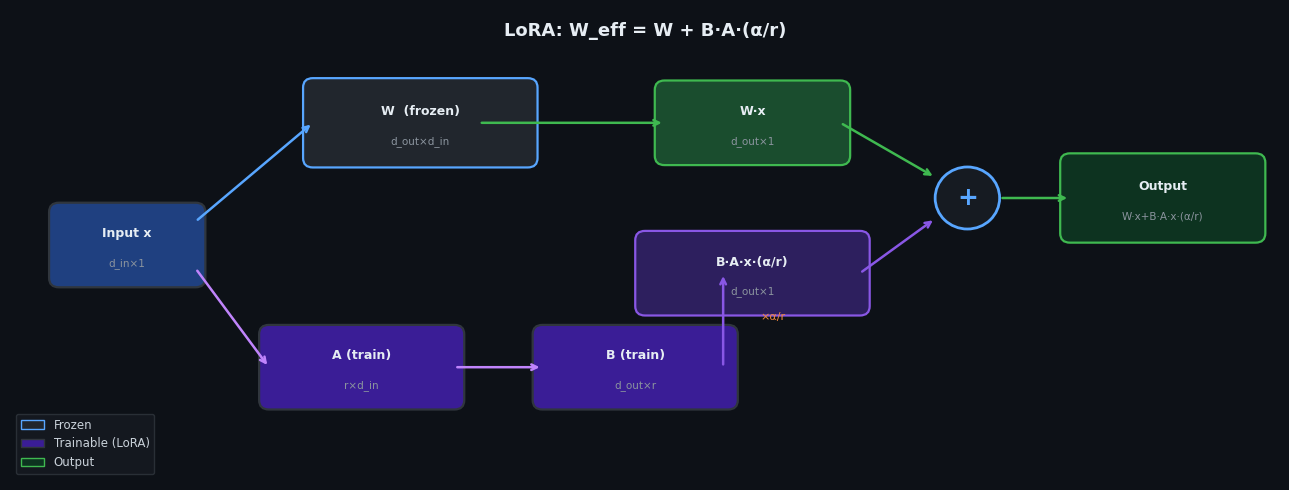

In [21]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.set_xlim(0, 13)
ax.set_ylim(0, 5)
ax.axis('off')

def box(cx, cy, w, h, fc, label, sub=None, ec='#30363d'):
    ax.add_patch(mpatches.FancyBboxPatch(
        (cx-w/2, cy-h/2), w, h, boxstyle='round,pad=0.1',
        facecolor=fc, edgecolor=ec, linewidth=1.6))
    dy = 0.12 if sub else 0
    ax.text(cx, cy+dy, label, ha='center', va='center',
            color='#e6edf3', fontsize=9, fontweight='bold')
    if sub:
        ax.text(cx, cy-0.2, sub, ha='center', va='center',
                color='#8b949e', fontsize=7.5)

def arr(x1,y1,x2,y2,col='#8b949e'):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.8))

ax.text(6.5, 4.72, 'LoRA: W_eff = W + B·A·(α/r)',
        ha='center', color='#e6edf3', fontsize=13, fontweight='bold')

# nodes
box(1.2,  2.5, 1.4, 0.7, '#1f4080', 'Input x',     'd_in×1')
box(4.2,  3.8, 2.2, 0.75,'#21262d', 'W  (frozen)',  'd_out×d_in', ec='#58a6ff')
box(3.6,  1.2, 1.9, 0.7, '#3a1d96', 'A (train)',    'r×d_in')
box(6.4,  1.2, 1.9, 0.7, '#3a1d96', 'B (train)',    'd_out×r')
box(7.6,  3.8, 1.8, 0.7, '#1a4d2e', 'W·x',         'd_out×1',   ec='#3fb950')
box(7.6,  2.2, 2.2, 0.7, '#2d1f5e', 'B·A·x·(α/r)', 'd_out×1',   ec='#8957e5')
ax.add_patch(plt.Circle((9.8,3.0), 0.33, facecolor='#161b22',
             edgecolor='#58a6ff', linewidth=2.0))
ax.text(9.8, 3.0, '+', ha='center', va='center',
        color='#58a6ff', fontsize=18, fontweight='bold')
box(11.8, 3.0, 1.9, 0.75,'#0d3320', 'Output',      'W·x+B·A·x·(α/r)', ec='#3fb950')

# arrows
arr(1.9, 2.75, 3.1, 3.8,  '#58a6ff')  # x→W
arr(1.9, 2.25, 2.65,1.2,  '#c084fc')  # x→A
arr(4.8, 3.8,  6.7, 3.8,  '#3fb950')  # W→Wx
arr(4.55,1.2,  5.45,1.2,  '#c084fc')  # A→B
arr(7.3, 1.2,  7.3, 2.2,  '#8957e5')  # B→BAx  (scale applied here)
arr(8.5, 3.8,  9.47,3.22, '#3fb950')  # Wx→+
arr(8.7, 2.2,  9.47,2.78, '#8957e5')  # BAx→+
arr(10.13,3.0, 10.85,3.0, '#3fb950')  # +→output

# scale label on B→BAx arrow
ax.text(7.68, 1.7, '×α/r', color='#f0883e', fontsize=8, ha='left')

patches = [
    mpatches.Patch(facecolor='#21262d', edgecolor='#58a6ff', label='Frozen'),
    mpatches.Patch(facecolor='#3a1d96', edgecolor='#30363d', label='Trainable (LoRA)'),
    mpatches.Patch(facecolor='#0d3320', edgecolor='#3fb950', label='Output'),
]
ax.legend(handles=patches, loc='lower left', facecolor='#161b22',
          edgecolor='#30363d', labelcolor='#c9d1d9', fontsize=8.5)

plt.tight_layout()
plt.show()